In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from pytorch_transformers import BertTokenizer, BertForSequenceClassification
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
train_df = pd.read_csv('../chap10/data/training.txt', sep='\t')
valid_df = pd.read_csv('../chap10/data/validing.txt', sep='\t')
test_df = pd.read_csv('../chap10/data/testing.txt', sep='\t')

In [3]:
train_df.head()

,id,document,label
0,5686145,당시 대박쳤던 영화..괜찮다!!,1
1,8392466,억지스러운 시나리오..지루한 전개.. 1편 보다 못한 구성등.. 2편은 안나오는게 ...,0
2,3398398,ㅋㅋㅋㅋㅋㅋㅋㅋ 반도 안되는 영화,0
3,2504572,이 영화가 평점이 높은 이유를 모르겠어..ㅡ.ㅡ::,0
4,1747519,"평생 기억할만한 영화,정상적인 소재는 아니지만",1


In [4]:
class Datasets(Dataset):
    def __init__(self, df):
        self.df = df
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # ← 반드시 캐스팅
        text = str(self.df.iloc[idx, 1])
        label = int(self.df.iloc[idx, 2])
        return text, label


In [5]:
def collate_fn(batch):
    # batch: [(text, label), (text, label), ...]
    texts  = [str(x[0]) for x in batch]                       # list[str]
    labels = torch.tensor([int(x[1]) for x in batch], dtype=torch.long)  # LongTensor
    return texts, labels

# DataLoader들 교체
train_dataset = Datasets(train_df)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0, collate_fn=collate_fn)

valid_dataset = Datasets(valid_df)
valid_loader  = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn)  # ← 검증은 일반적으로 shuffle=False

test_dataset  = Datasets(test_df)
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn)  # ← 테스트도 False

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
model_name = "beomi/kcbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=2)
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at beomi/kcbert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30000, 768, padding_idx=0)
      (position_embeddings): Embedding(300, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [7]:
def save_checkpoint(save_path, model, valid_loss):
    if save_path == None:
        return    
    state_dict = {'model_state_dict': model.state_dict(),
                  'valid_loss': valid_loss}
    
    torch.save(state_dict, save_path)
    print(f'Model saved to ==> {save_path}')

def load_checkpoint(load_path, model):    
    if load_path==None:
        return    
    state_dict = torch.load(load_path, map_location=device)
    print(f'Model loaded from <== {load_path}')
    
    model.load_state_dict(state_dict['model_state_dict'])
    return state_dict['valid_loss']

def save_metrics(save_path, train_loss_list, valid_loss_list, global_steps_list):
    if save_path == None:
        return    
    state_dict = {'train_loss_list': train_loss_list,
                  'valid_loss_list': valid_loss_list,
                  'global_steps_list': global_steps_list}    
    torch.save(state_dict, save_path)
    print(f'Model saved to ==> {save_path}')

def load_metrics(load_path):
    if load_path==None:
        return    
    state_dict = torch.load(load_path, map_location=device)
    print(f'Model loaded from <== {load_path}')    
    return state_dict['train_loss_list'], state_dict['valid_loss_list'], state_dict['global_steps_list']

In [8]:
# 문자열 배치를 확실히 list[str]로 맞춰주는 헬퍼
def _to_str_list(x):
    if isinstance(x, (list, tuple)):
        # 2중 리스트([[..],[..]])가 오면 한 겹 평탄화 시도
        if len(x) > 0 and not (isinstance(x[0], str) or x[0] is None):
            try:
                x = [xi[0] if isinstance(xi, (list, tuple)) else xi for xi in x]
            except Exception:
                pass
        return list(x)
    return [x]


In [9]:
import os
import torch

def train(
    model,
    optimizer,
    num_epochs: int = 5,
    eval_every: int | None = None,   # ← 기본값 None (함수 안에서 안전하게 계산)
    max_length: int = 128,
    best_valid_loss: float = float("inf"),
):
    model.train()
    os.makedirs("./bertmodel", exist_ok=True)

    running_loss = 0.0
    global_step = 0
    train_loss_list, valid_loss_list, global_steps_list = [], [], []

    # 안전하게 설정 (함수 정의 시점에 train_loader가 없더라도 OK)
    if eval_every is None:
        eval_every = max(1, len(train_loader) // 2)

    for epoch in range(num_epochs):
        for texts, labels in train_loader:
            optimizer.zero_grad()

            # ★ 반드시 list[str] 보장
            enc = tokenizer(
                _to_str_list(texts),
                padding=True, truncation=True, max_length=max_length,
                return_tensors="pt"
            )
            enc = {k: v.to(device) for k, v in enc.items()}

            if not torch.is_tensor(labels):
                labels = torch.tensor(labels)
            labels = labels.to(device).long()

            out = model(**enc, labels=labels)  # HF가 CE loss 계산
            loss = out.loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 선택
            optimizer.step()

            running_loss += loss.item()
            global_step += 1

            # 주기적 검증
            if global_step % eval_every == 0:
                model.eval()
                valid_running_loss = 0.0

                with torch.no_grad():
                    for v_texts, v_labels in valid_loader:
                        v_enc = tokenizer(
                            _to_str_list(v_texts),  # ★ 여기서도 list[str] 보장
                            padding=True, truncation=True, max_length=max_length,
                            return_tensors="pt"
                        )
                        v_enc = {k: v.to(device) for k, v in v_enc.items()}

                        if not torch.is_tensor(v_labels):
                            v_labels = torch.tensor(v_labels)
                        v_labels = v_labels.to(device).long()

                        v_out = model(**v_enc, labels=v_labels)
                        v_loss = v_out.loss
                        valid_running_loss += v_loss.item()

                avg_train_loss = running_loss / eval_every
                avg_valid_loss = valid_running_loss / max(1, len(valid_loader))
                train_loss_list.append(avg_train_loss)
                valid_loss_list.append(avg_valid_loss)
                global_steps_list.append(global_step)

                print(
                    f"Epoch [{epoch+1}/{num_epochs}] "
                    f"Step [{global_step}/{num_epochs*len(train_loader)}] "
                    f"Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f}"
                )

                if avg_valid_loss < best_valid_loss:
                    best_valid_loss = avg_valid_loss
                    save_checkpoint("./bertmodel/model.pt", model, best_valid_loss)
                    save_metrics("./bertmodel/metrics.pt",
                                 train_loss_list, valid_loss_list, global_steps_list)

                running_loss = 0.0
                model.train()

    save_metrics("./bertmodel/metrics.pt",
                 train_loss_list, valid_loss_list, global_steps_list)
    print("훈련 종료!")


In [10]:
optimizer = optim.Adam(model.parameters(), lr=2e-5)
train(model=model, optimizer=optimizer)

Epoch [1/5] Step [638/6380] Train Loss: 0.4004 | Valid Loss: 0.3286
Model saved to ==> ./bertmodel/model.pt
Model saved to ==> ./bertmodel/metrics.pt
Epoch [1/5] Step [1276/6380] Train Loss: 0.3339 | Valid Loss: 0.3356
Epoch [2/5] Step [1914/6380] Train Loss: 0.2141 | Valid Loss: 0.3955
Epoch [2/5] Step [2552/6380] Train Loss: 0.2234 | Valid Loss: 0.3842
Epoch [3/5] Step [3190/6380] Train Loss: 0.1253 | Valid Loss: 0.5880
Epoch [3/5] Step [3828/6380] Train Loss: 0.1551 | Valid Loss: 0.4405
Epoch [4/5] Step [4466/6380] Train Loss: 0.0747 | Valid Loss: 0.6158
Epoch [4/5] Step [5104/6380] Train Loss: 0.1100 | Valid Loss: 0.6759
Epoch [5/5] Step [5742/6380] Train Loss: 0.0633 | Valid Loss: 0.8302
Epoch [5/5] Step [6380/6380] Train Loss: 0.0742 | Valid Loss: 0.6576
Model saved to ==> ./bertmodel/metrics.pt
훈련 종료!


Model loaded from <== ./bertmodel/metrics.pt


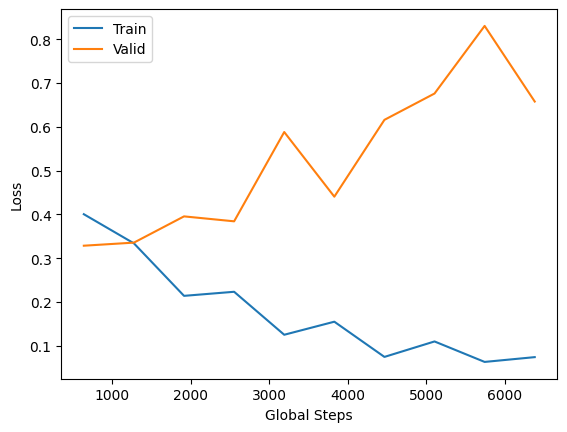

In [11]:
train_loss_list, valid_loss_list, global_steps_list = load_metrics('./bertmodel/metrics.pt')
plt.plot(global_steps_list, train_loss_list, label='Train')
plt.plot(global_steps_list, valid_loss_list, label='Valid')
plt.xlabel('Global Steps')
plt.ylabel('Loss')
plt.legend()
plt.show() 